In [16]:
# Importações básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Bibliotecas especializadas
import math
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

print(" Bibliotecas importadas!")

 Bibliotecas importadas!


Carregamento e Exploração de Dados

In [17]:
from pathlib import Path
import pandas as pd

path = Path('../../data/Airbnb Prices in European Cities/raw')

file_name = "london_weekends.csv"
file_path = path / file_name

df = pd.read_csv(file_path)

print("Lido")


Lido


In [18]:
cols_lfs = [
    'version https://git-lfs.github.com/spec/v1',
    'oid sha256',
    'size'
]

df = df.drop(columns=[c for c in cols_lfs if c in df.columns])


Análise Exploratória Estrutural

In [19]:
# 1. Informações básicas do dataset
print("\n1️⃣ INFORMAÇÕES GERAIS:")
print(f"Dimensões: {df.shape}")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


1️⃣ INFORMAÇÕES GERAIS:
Dimensões: (5379, 20)
Memória: 1.03 MB


In [20]:
# 2. Tipos de dados
print("\n2️⃣ TIPOS DE DADOS:")
print(df.dtypes)


2️⃣ TIPOS DE DADOS:
Unnamed: 0                      int64
realSum                       float64
room_type                      object
room_shared                      bool
room_private                     bool
person_capacity               float64
host_is_superhost                bool
multi                           int64
biz                             int64
cleanliness_rating            float64
guest_satisfaction_overall    float64
bedrooms                        int64
dist                          float64
metro_dist                    float64
attr_index                    float64
attr_index_norm               float64
rest_index                    float64
rest_index_norm               float64
lng                           float64
lat                           float64
dtype: object


In [21]:
# 3. Primeiras linhas
print("\n3️⃣ PRIMEIRAS 5 LINHAS:")
display(df.head())


3️⃣ PRIMEIRAS 5 LINHAS:


,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
0,0,121.122322,Private room,False,True,2.0,False,0,0,6.0,69.0,1,5.734117,0.437094,222.882243,15.493414,470.088502,8.413765,-0.04975,51.52570
1,1,195.912416,Private room,False,True,2.0,False,1,0,10.0,96.0,1,4.788905,1.464050,235.385841,16.362588,530.133525,9.488466,-0.08475,51.54210
2,2,193.325337,Private room,False,True,3.0,False,1,0,10.0,95.0,1,4.596677,0.450306,268.913812,18.693247,548.987610,9.825922,-0.14585,51.54802
3,3,180.389943,Private room,False,True,2.0,False,1,0,9.0,87.0,1,2.054769,0.132670,472.381314,32.837067,1021.271062,18.278973,-0.10611,51.52108
4,4,405.700981,Entire home/apt,False,False,3.0,False,0,1,7.0,65.0,0,4.491277,0.354108,318.491470,22.139584,692.775411,12.399473,-0.18797,51.49399


In [22]:
# 4. Informações detalhadas
print("\n4️⃣ INFO DETALHADA:")
df.info()


4️⃣ INFO DETALHADA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5379 entries, 0 to 5378
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  5379 non-null   int64  
 1   realSum                     5379 non-null   float64
 2   room_type                   5379 non-null   object 
 3   room_shared                 5379 non-null   bool   
 4   room_private                5379 non-null   bool   
 5   person_capacity             5379 non-null   float64
 6   host_is_superhost           5379 non-null   bool   
 7   multi                       5379 non-null   int64  
 8   biz                         5379 non-null   int64  
 9   cleanliness_rating          5379 non-null   float64
 10  guest_satisfaction_overall  5379 non-null   float64
 11  bedrooms                    5379 non-null   int64  
 12  dist                        5379 non-null   float64
 13  metro_dist  

In [23]:
# 5. Estatísticas descritivas
print("\n5️⃣ ESTATÍSTICAS DESCRITIVAS:")
display(df.describe())


5️⃣ ESTATÍSTICAS DESCRITIVAS:


,Unnamed: 0,realSum,person_capacity,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
count,5379.00000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000
mean,2689.00000,364.389747,2.857966,0.279792,0.357873,9.193902,90.921175,1.133110,5.327620,1.016534,294.575060,20.477061,625.612765,11.197378,-0.114782,51.503457
std,1552.92788,437.742534,1.251068,0.448939,0.479419,1.151321,11.289857,0.577676,2.705986,1.265193,170.516734,11.853283,388.206414,6.948218,0.067520,0.031966
min,0.00000,54.328653,2.000000,0.000000,0.000000,2.000000,20.000000,0.000000,0.040561,0.013875,68.740518,4.778421,140.521722,2.515094,-0.251700,51.414400
25%,1344.50000,174.510219,2.000000,0.000000,0.000000,9.000000,87.000000,1.000000,3.545684,0.324035,177.224481,12.319565,382.129695,6.839456,-0.169960,51.485690
50%,2689.00000,268.115431,2.000000,0.000000,0.000000,10.000000,94.000000,1.000000,4.939138,0.536131,247.646069,17.214844,527.347208,9.438596,-0.118130,51.509640
75%,4033.50000,438.274654,4.000000,1.000000,1.000000,10.000000,99.000000,1.000000,6.838065,1.090765,361.070549,25.099422,764.221221,13.678228,-0.067725,51.525720
max,5378.00000,12937.275101,6.000000,1.000000,1.000000,10.000000,100.000000,8.000000,17.321199,9.174094,1438.561236,100.000000,5587.136047,100.000000,0.120180,51.575820


In [24]:
# 6. Análise de valores únicos
print("\n6️⃣ VALORES ÚNICOS POR COLUNA:")
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count}")


6️⃣ VALORES ÚNICOS POR COLUNA:
Unnamed: 0: 5379
realSum: 1605
room_type: 3
room_shared: 2
room_private: 2
person_capacity: 5
host_is_superhost: 2
multi: 2
biz: 2
cleanliness_rating: 9
guest_satisfaction_overall: 48
bedrooms: 7
dist: 5379
metro_dist: 5379
attr_index: 5379
attr_index_norm: 5379
rest_index: 5379
rest_index_norm: 5379
lng: 4551
lat: 4017


Análise de Missing Values

In [25]:
# 1. Contagem de missing values
print("\n1️⃣ MISSING VALUES POR COLUNA:")
missing_data = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)
print(missing_data)


1️⃣ MISSING VALUES POR COLUNA:
Empty DataFrame
Columns: [Coluna, Missing_Count, Missing_Percent]
Index: []


Análise Exploratória Univariada

In [26]:
# Separar variáveis por tipo
numeric_vars = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df.select_dtypes(include=['object', 'bool']).columns.tolist()

In [27]:
print(f"Variáveis numéricas: {numeric_vars}")
print(f"Variáveis categóricas: {categorical_vars}")

Variáveis numéricas: ['Unnamed: 0', 'realSum', 'person_capacity', 'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'attr_index', 'attr_index_norm', 'rest_index', 'rest_index_norm', 'lng', 'lat']
Variáveis categóricas: ['room_type', 'room_shared', 'room_private', 'host_is_superhost']


In [28]:
# 1. ANÁLISE DE VARIÁVEIS NUMÉRICAS
print("\n1️⃣ ANÁLISE DE VARIÁVEIS NUMÉRICAS:")


1️⃣ ANÁLISE DE VARIÁVEIS NUMÉRICAS:


In [29]:
# Estatísticas descritivas detalhadas
for var in numeric_vars:
    if var in df.columns:
        print(f"\n📊 {var.upper()}:")
        data = df[var].dropna()

        # Estatísticas básicas
        print(f"  Mean: {data.mean():.2f}")
        print(f"  Median: {data.median():.2f}")
        print(f"  Std: {data.std():.2f}")
        print(f"  Skewness: {stats.skew(data):.2f}")
        print(f"  Kurtosis: {stats.kurtosis(data):.2f}")

        # Outliers (IQR method)
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")


📊 UNNAMED: 0:
  Mean: 2689.00
  Median: 2689.00
  Std: 1552.93
  Skewness: 0.00
  Kurtosis: -1.20
  Outliers: 0 (0.0%)

📊 REALSUM:
  Mean: 364.39
  Median: 268.12
  Std: 437.74
  Skewness: 15.08
  Kurtosis: 375.60
  Outliers: 297 (5.5%)

📊 PERSON_CAPACITY:
  Mean: 2.86
  Median: 2.00
  Std: 1.25
  Skewness: 1.24
  Kurtosis: 0.37
  Outliers: 0 (0.0%)

📊 MULTI:
  Mean: 0.28
  Median: 0.00
  Std: 0.45
  Skewness: 0.98
  Kurtosis: -1.04
  Outliers: 0 (0.0%)

📊 BIZ:
  Mean: 0.36
  Median: 0.00
  Std: 0.48
  Skewness: 0.59
  Kurtosis: -1.65
  Outliers: 0 (0.0%)

📊 CLEANLINESS_RATING:
  Mean: 9.19
  Median: 10.00
  Std: 1.15
  Skewness: -2.54
  Kurtosis: 9.92
  Outliers: 324 (6.0%)

📊 GUEST_SATISFACTION_OVERALL:
  Mean: 90.92
  Median: 94.00
  Std: 11.29
  Skewness: -2.71
  Kurtosis: 11.22
  Outliers: 204 (3.8%)

📊 BEDROOMS:
  Mean: 1.13
  Median: 1.00
  Std: 0.58
  Skewness: 1.49
  Kurtosis: 7.52
  Outliers: 1324 (24.6%)

📊 DIST:
  Mean: 5.33
  Median: 4.94
  Std: 2.71
  Skewness: 0.96
  Ku

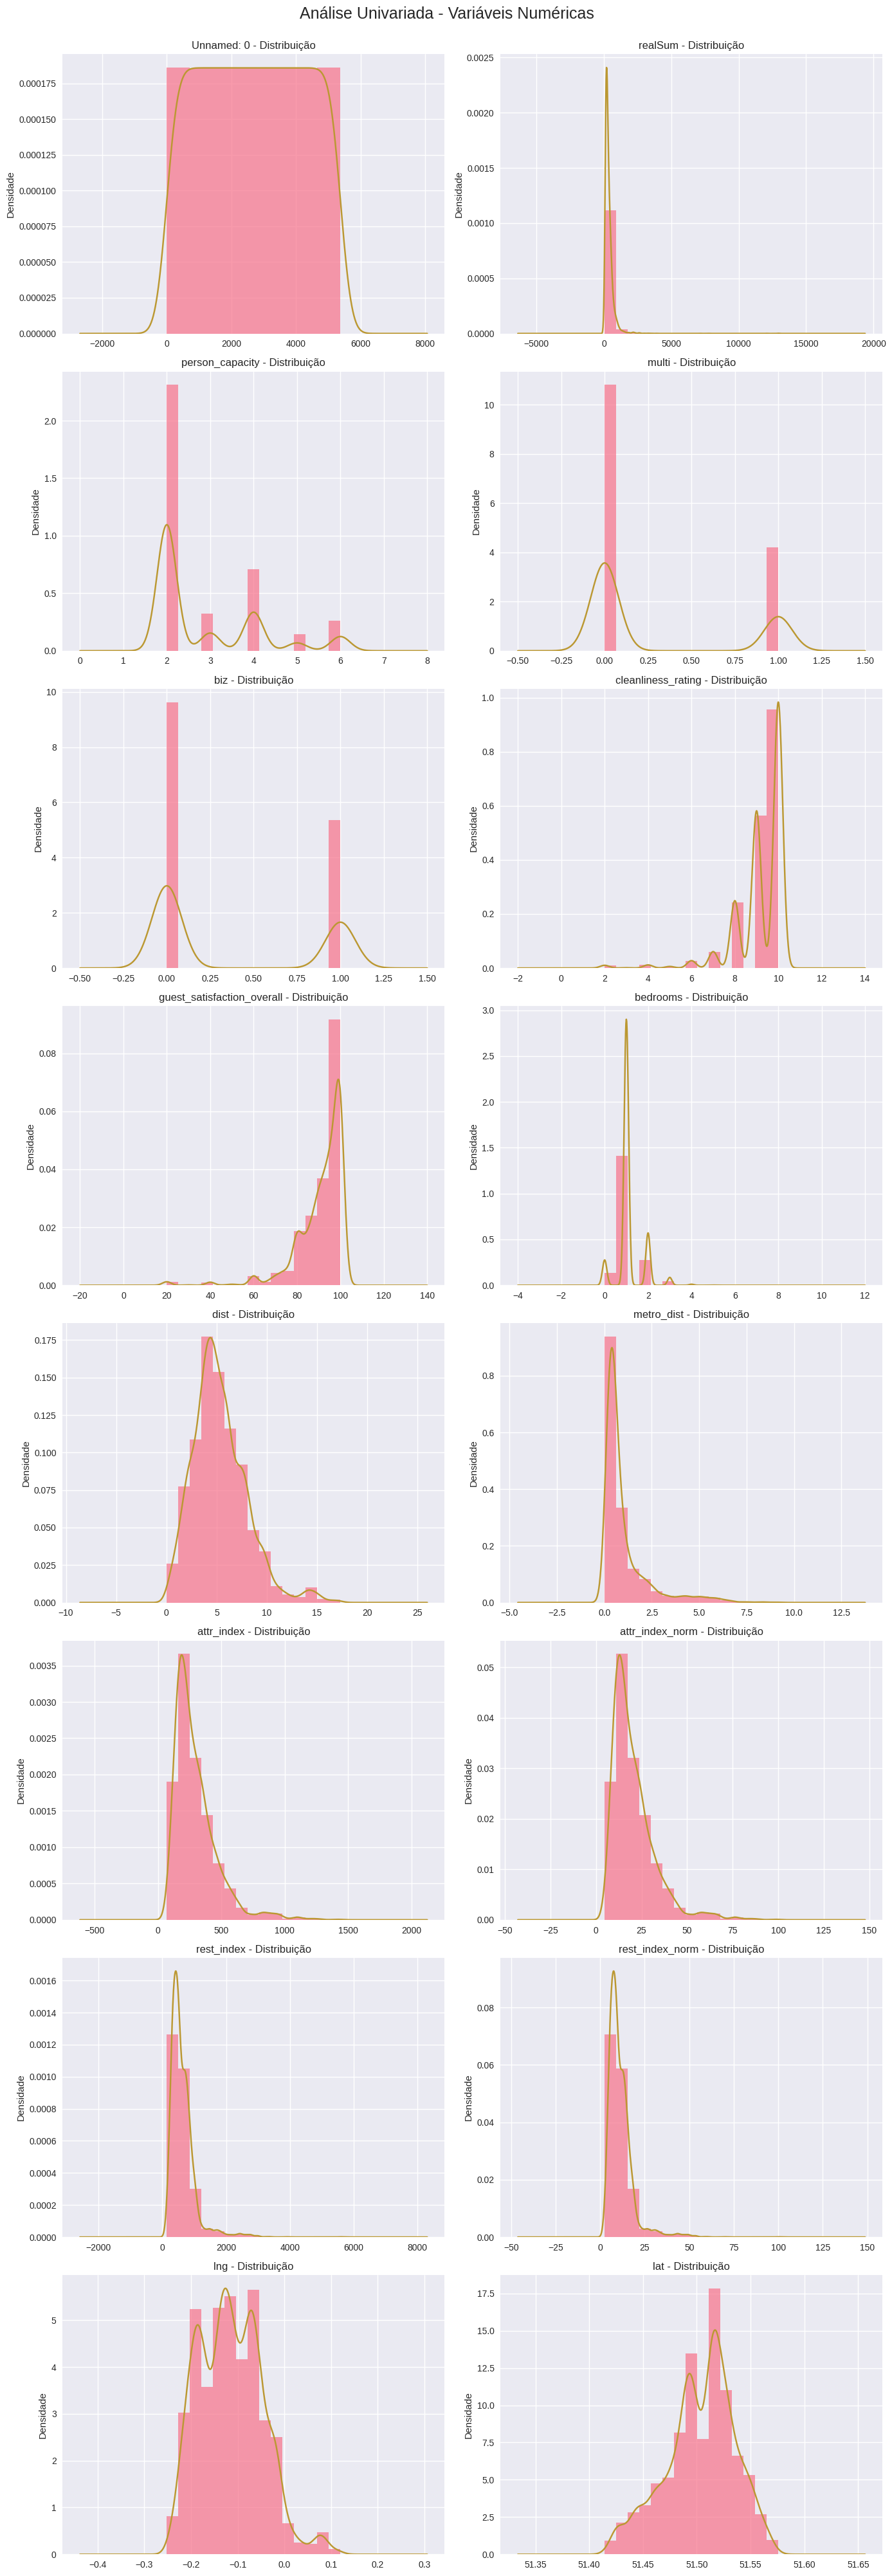

In [49]:
# Total das variáveis numéricas
vars_to_plot = numeric_vars[:16]   
cols = 2
rows = 8

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
fig.suptitle('Análise Univariada - Variáveis Numéricas', fontsize=18, y=1.0)

axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]

    
    # Histograma
    ax.hist(df[var].dropna(), bins=15, alpha=0.7, density=True)

    # Linha de densidade (KDE)
    df[var].dropna().plot.density(ax=ax)

    ax.set_title(f'{var} - Distribuição')
    ax.set_ylabel('Densidade')

plt.tight_layout()
plt.show()


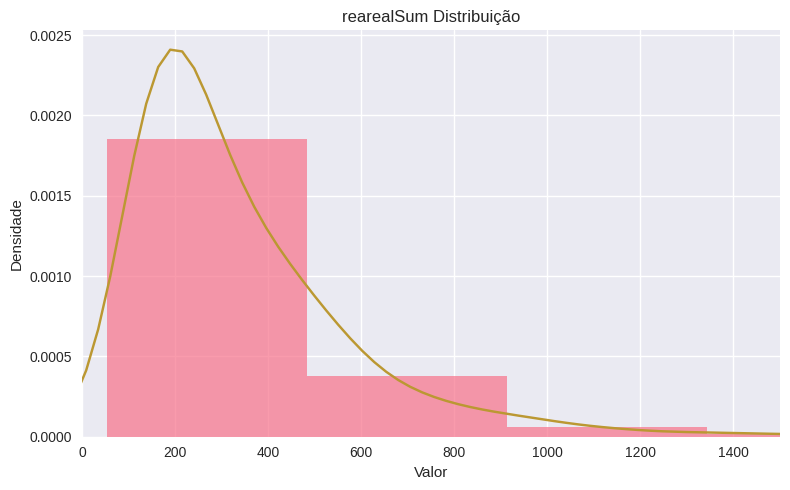

In [50]:
plt.figure(figsize=(8, 5))

plt.hist(df["realSum"].dropna(), bins=30, alpha=0.7, density=True)
df["realSum"].dropna().plot.density()

plt.title("rearealSum Distribuição")
plt.xlabel("Valor")
plt.ylabel("Densidade")

plt.xlim(0, 1500)   

plt.tight_layout()
plt.show()


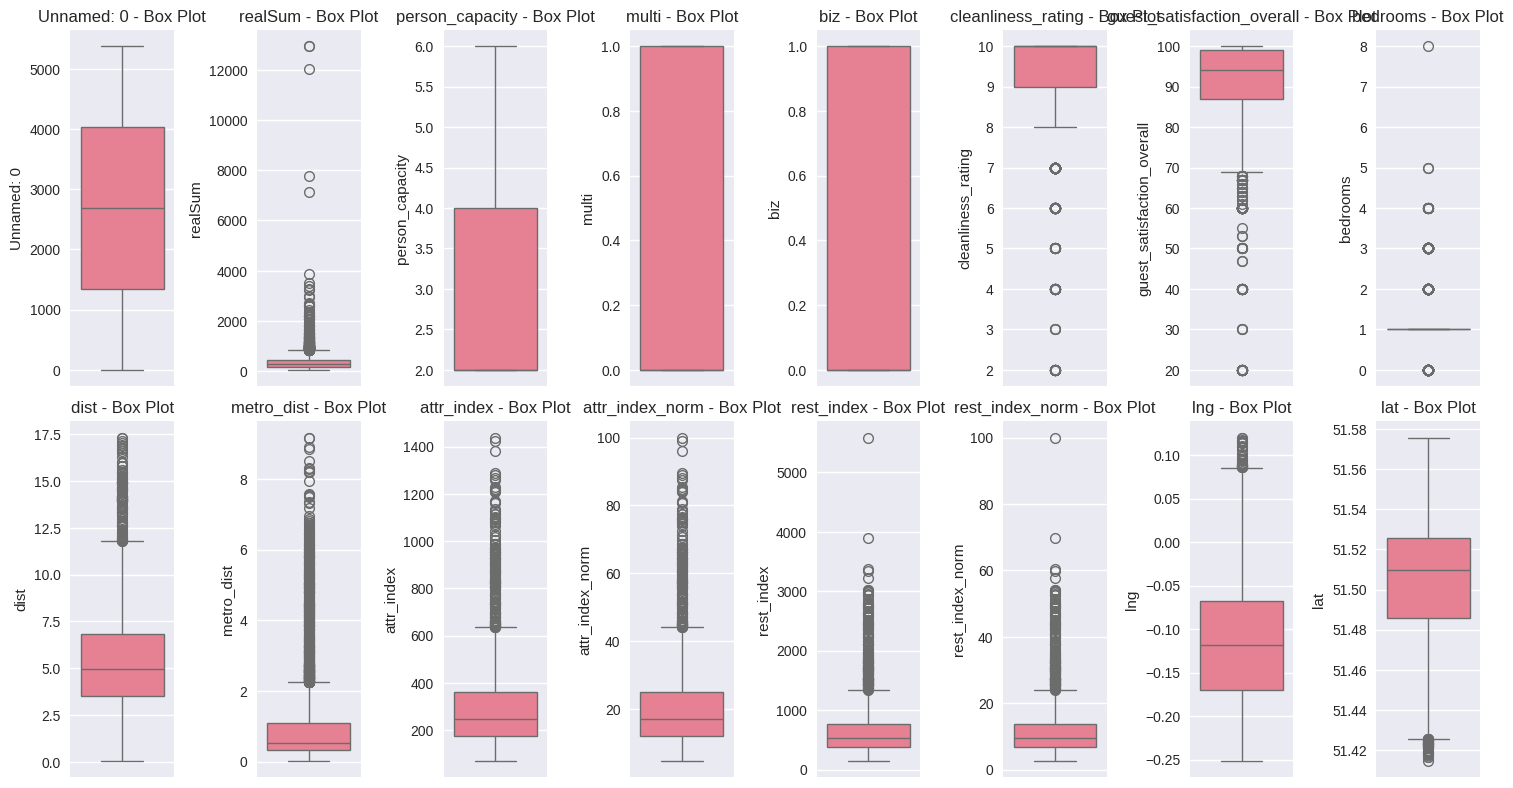

In [ ]:
# Box plots para identificar outliers
plt.figure(figsize=(15, 8))
numeric_data = df[numeric_vars].select_dtypes(include=[np.number])

variables_to_plot = numeric_data.columns[:16]
for i, var in enumerate(variables_to_plot):
    plt.subplot(2, 8, i+1)
    sns.boxplot(y=df[var])
    plt.title(f'{var} - Box Plot')
plt.tight_layout()
plt.show()

In [33]:
# 2. ANÁLISE DE VARIÁVEIS CATEGÓRICAS
print("\n2️⃣ ANÁLISE DE VARIÁVEIS CATEGÓRICAS:")


2️⃣ ANÁLISE DE VARIÁVEIS CATEGÓRICAS:


In [34]:
# Análise de frequências
for var in categorical_vars:
    if var in df.columns:
        print(f"\n📊 {var.upper()}:")
        freq_table = df[var].value_counts()
        freq_percent = df[var].value_counts(normalize=True) * 100

        freq_df = pd.DataFrame({
            'Frequência': freq_table,
            'Percentual': freq_percent
        })
        print(freq_df.head(10))

        # Medida de concentração (Índice de Herfindahl)
        herfindahl = (freq_percent/100).pow(2).sum()
        print(f"  Índice de Herfindahl: {herfindahl:.3f}")
        print(f"  Entropia: {stats.entropy(freq_table):.3f}")


📊 ROOM_TYPE:
                 Frequência  Percentual
room_type                              
Private room           2934   54.545455
Entire home/apt        2418   44.952593
Shared room              27    0.501952
  Índice de Herfindahl: 0.500
  Entropia: 0.717

📊 ROOM_SHARED:
             Frequência  Percentual
room_shared                        
False              5352   99.498048
True                 27    0.501952
  Índice de Herfindahl: 0.990
  Entropia: 0.032

📊 ROOM_PRIVATE:
              Frequência  Percentual
room_private                        
True                2934   54.545455
False               2445   45.454545
  Índice de Herfindahl: 0.504
  Entropia: 0.689

📊 HOST_IS_SUPERHOST:
                   Frequência  Percentual
host_is_superhost                        
False                    4484    83.36122
True                      895    16.63878
  Índice de Herfindahl: 0.723
  Entropia: 0.450


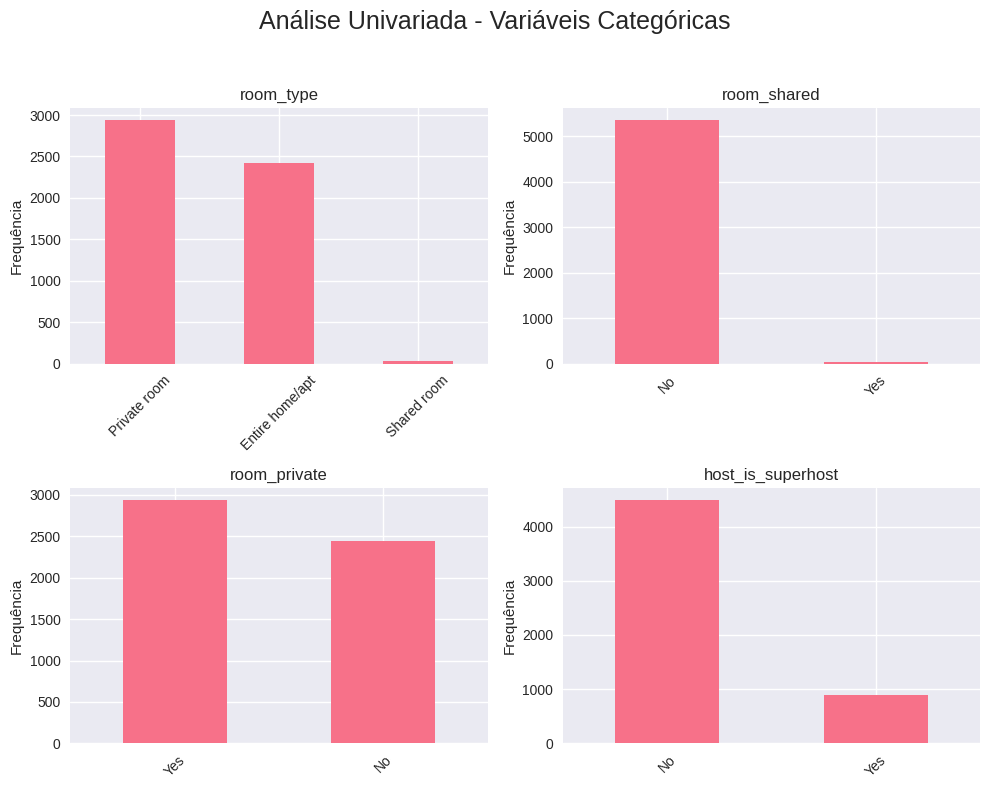

In [51]:

cols = 2
rows = math.ceil(len(categorical_vars)/2)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
axes = axes.flatten()  # facilita indexação mesmo quando rows*cols == 1

fig.suptitle('Análise Univariada - Variáveis Categóricas', fontsize=18)

for idx, var in enumerate(categorical_vars):
        ax = axes[idx]

        if df[var].dtype == 'bool':
                counts = df[var].map({True:'Yes', False:'No'}).value_counts()
        else:
                counts = df[var].value_counts().head(10)  

        counts.plot(kind='bar', ax=ax)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('')
        ax.set_ylabel('Frequência')
        ax.set_title(f'{var}')
        # ajusta o layout deixando espaço para o suptitle

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


ANÁLISE EXPLORATÓRIA BIVARIADA

In [36]:
# 1. CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS
print("\n1️⃣ MATRIZ DE CORRELAÇÃO:")


1️⃣ MATRIZ DE CORRELAÇÃO:


In [37]:
# Calcular matriz de correlação
correlation_matrix = df[numeric_vars].corr()

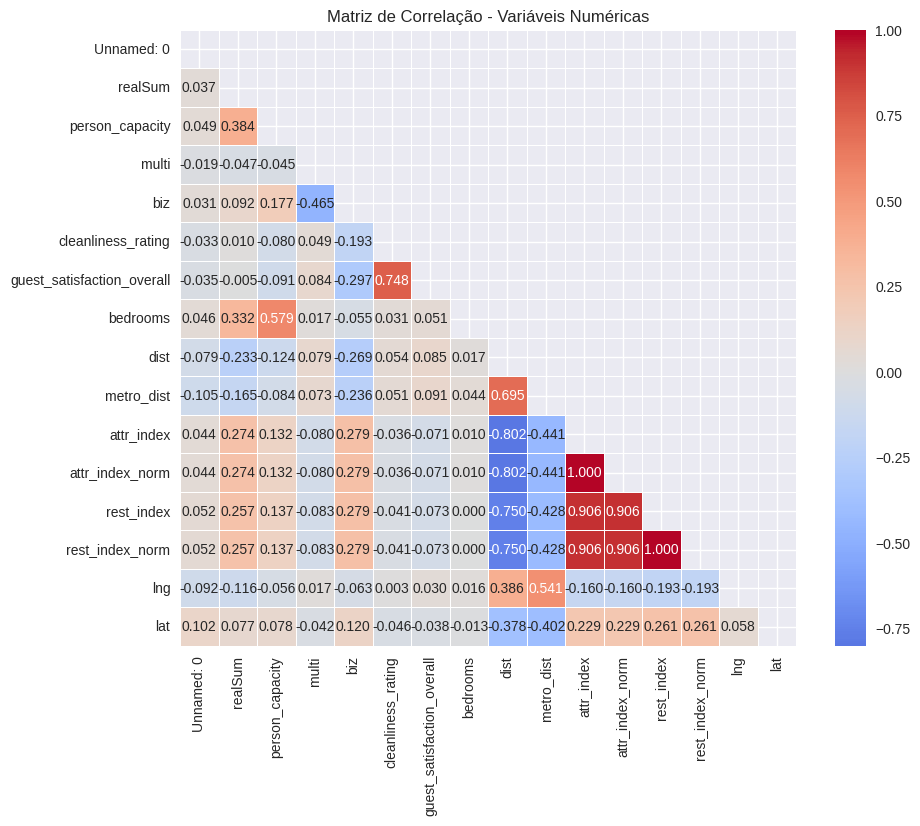

In [52]:
# Visualizar heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask, 
            annot=True, 
            cmap='coolwarm',
            center=0, 
            square=True, 
            linewidths=0.5,
            fmt=".3f",)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.show()

In [39]:
# Identificar correlações fortes
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:  # Correlação forte
            strong_corr.append({
                'var1': correlation_matrix.columns[i],
                'var2': correlation_matrix.columns[j],
                'correlation': corr_val
            })

In [40]:
if strong_corr:
    print("\n🔥 CORRELAÇÕES FORTES (|r| > 0.5):")
    for corr in strong_corr:
        print(f"  {corr['var1']} ↔ {corr['var2']}: {corr['correlation']:.3f}")


🔥 CORRELAÇÕES FORTES (|r| > 0.5):
  person_capacity ↔ bedrooms: 0.579
  cleanliness_rating ↔ guest_satisfaction_overall: 0.748
  dist ↔ metro_dist: 0.695
  dist ↔ attr_index: -0.802
  dist ↔ attr_index_norm: -0.802
  dist ↔ rest_index: -0.750
  dist ↔ rest_index_norm: -0.750
  metro_dist ↔ lng: 0.541
  attr_index ↔ attr_index_norm: 1.000
  attr_index ↔ rest_index: 0.906
  attr_index ↔ rest_index_norm: 0.906
  attr_index_norm ↔ rest_index: 0.906
  attr_index_norm ↔ rest_index_norm: 0.906
  rest_index ↔ rest_index_norm: 1.000


In [41]:
# 2. ANÁLISE TARGET vs VARIÁVEIS NUMÉRICAS
print("\n2️⃣ TARGET vs VARIÁVEIS NUMÉRICAS:")


2️⃣ TARGET vs VARIÁVEIS NUMÉRICAS:


In [55]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()

corr = correlation_matrix['realSum'].abs().sort_values(ascending=False)

top3 = corr.index[1:4].tolist()  # Ignora o próprio realSum
print("Top 3 variáveis mais correlacionadas ao realSum:", top3)


Top 3 variáveis mais correlacionadas ao realSum: ['person_capacity', 'bedrooms', 'attr_index']


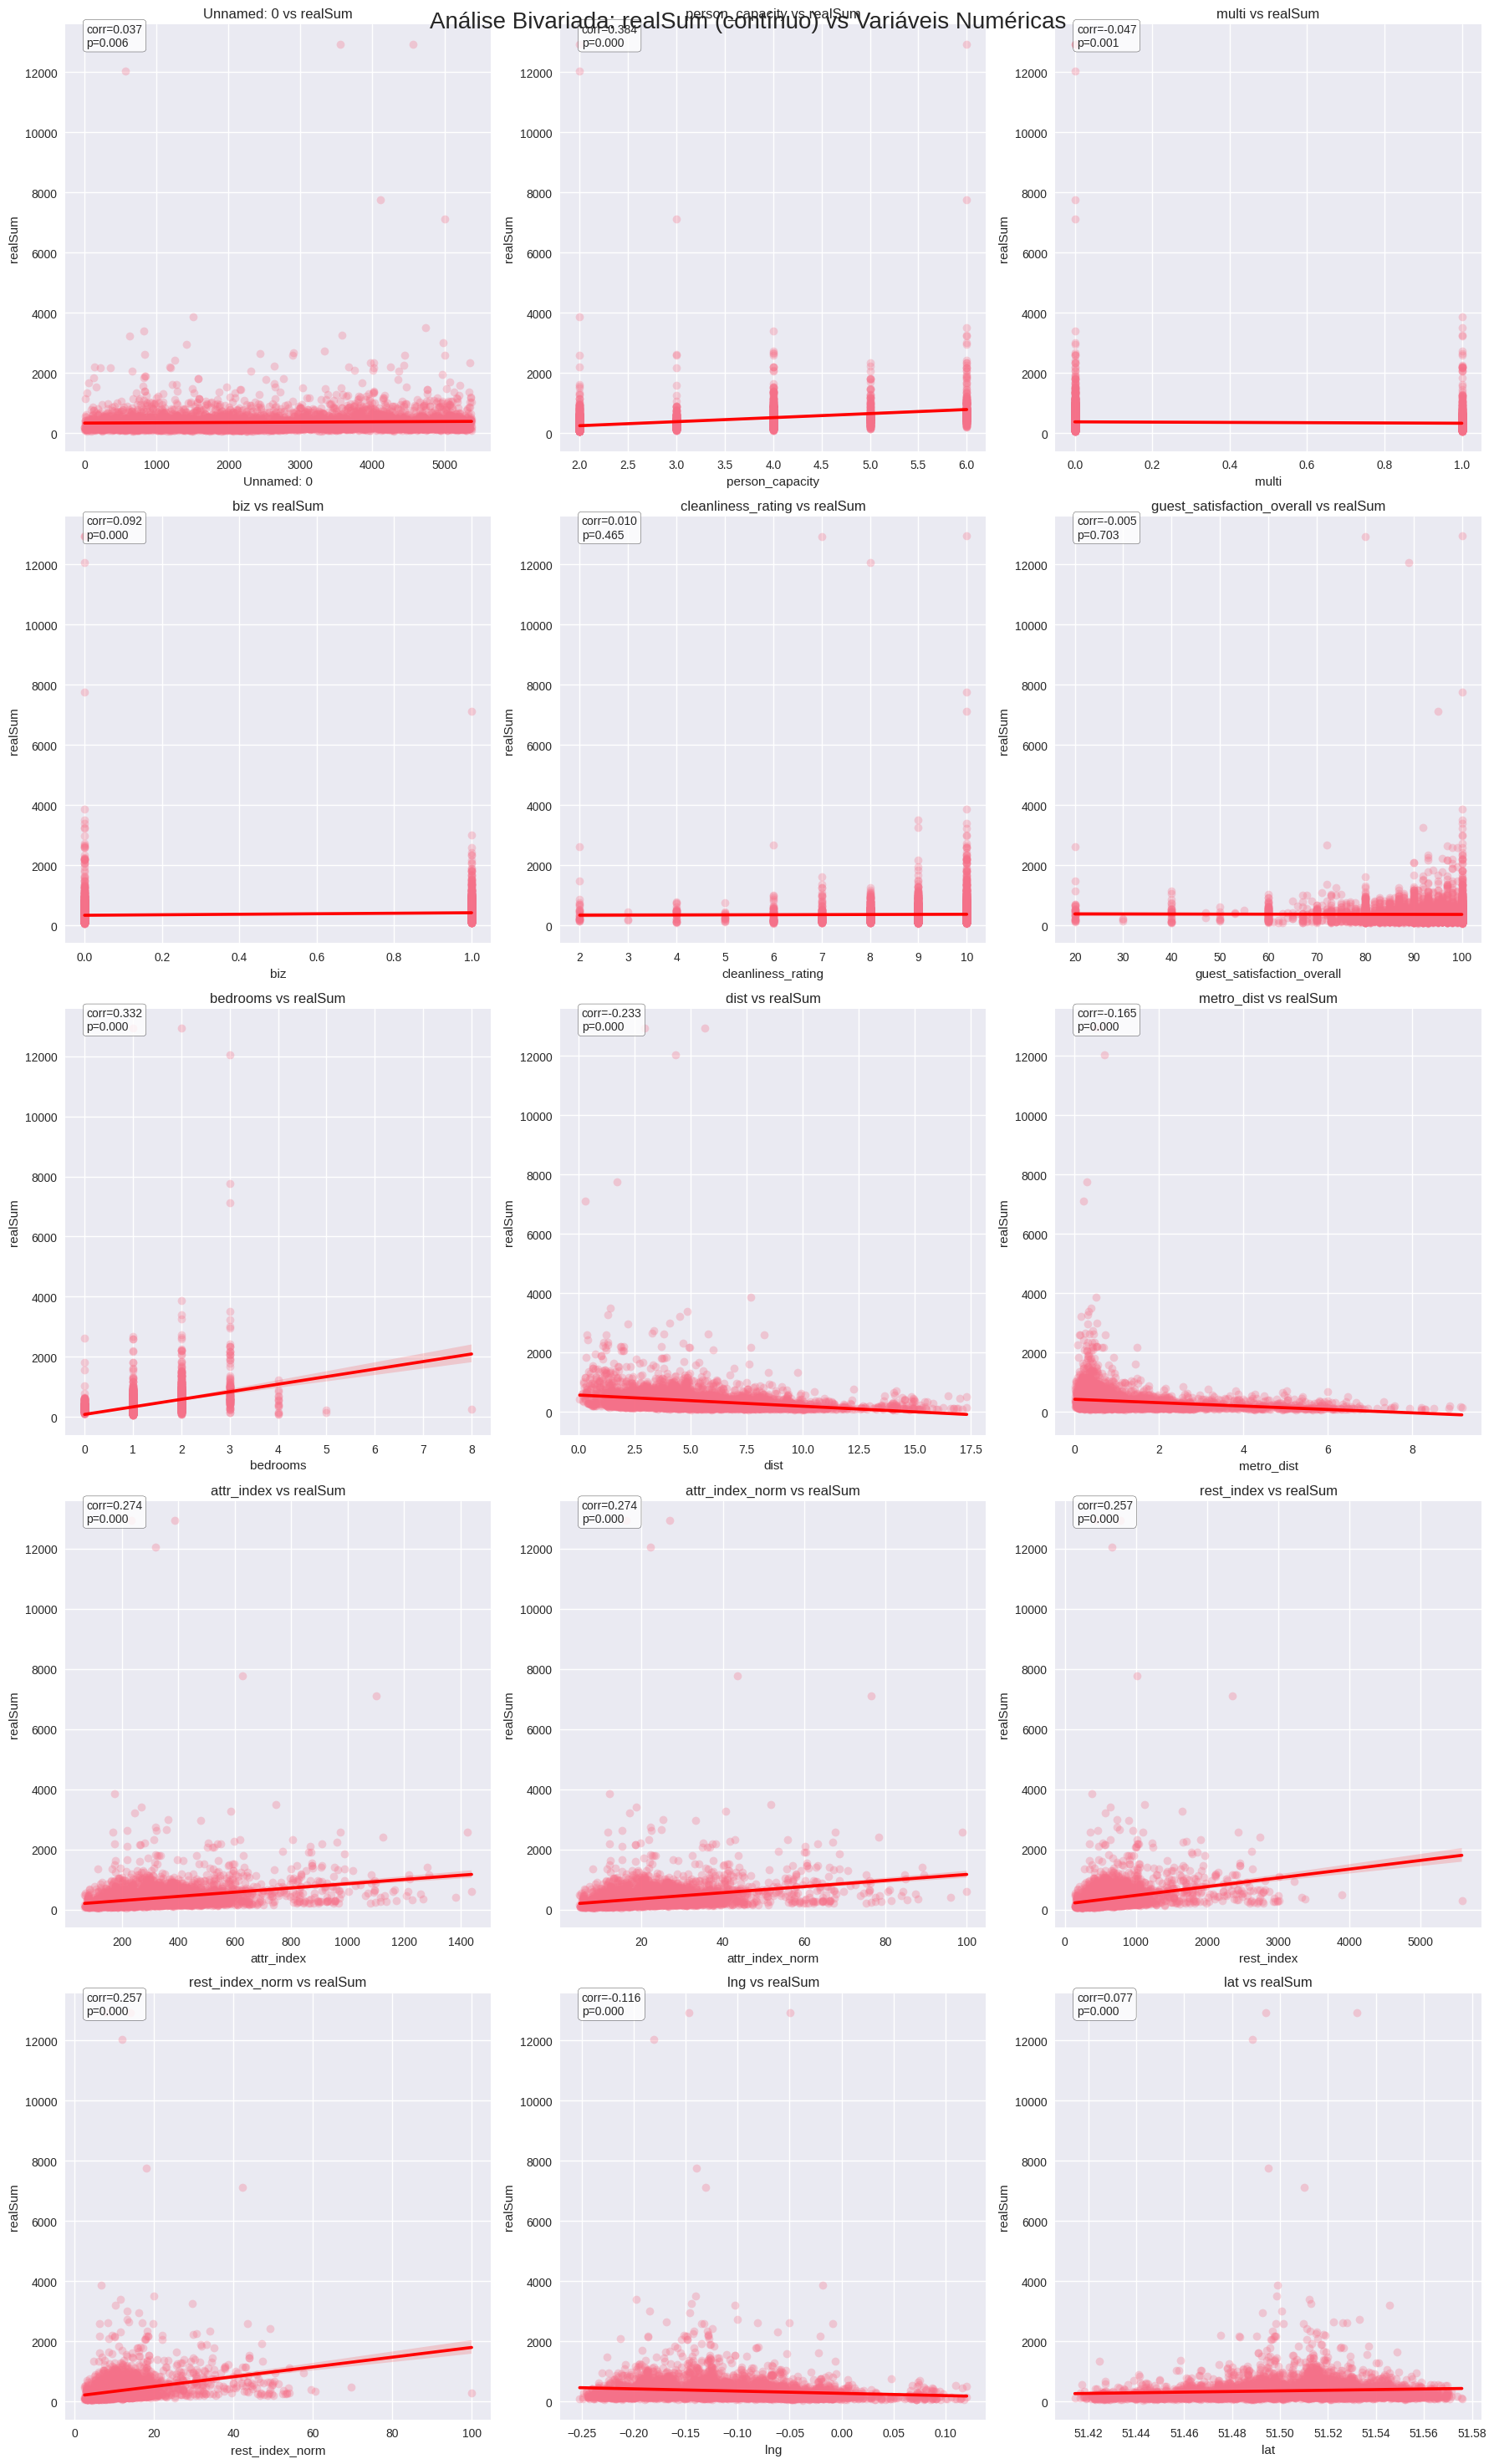

In [56]:

# Variáveis numéricas selecionadas para análise
target_var = 'realSum'
numeric_for_analysis = [var for var in numeric_vars if var != target_var]


n = len(numeric_for_analysis)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
axes = axes.flatten()

fig.suptitle(f'Análise Bivariada: {target_var} (contínuo) vs Variáveis Numéricas', fontsize=20)

for i, var in enumerate(numeric_for_analysis):

    if var not in df.columns:
        continue

    ax = axes[i]

    # Scatter plot + regressão linear
    sns.regplot(
        data=df,
        x=var,
        y=target_var,
        scatter_kws={'alpha': 0.3},
        line_kws={'color': 'red'},
        ax=ax
    )
    
    ax.set_title(f'{var} vs {target_var}')

    # Correlação Pearson
    x = df[var].dropna()
    y = df[target_var].dropna()

    corr, pval = pearsonr(x, y)

    # Texto do p-value e correlação
    ax.text(
        0.05, 0.95,
        f'corr={corr:.3f}\np={pval:.3f}',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

plt.tight_layout()
plt.show()


In [45]:
# 3. ANÁLISE TARGET vs VARIÁVEIS CATEGÓRICAS
print("\n3️⃣ TARGET vs VARIÁVEIS CATEGÓRICAS:")


3️⃣ TARGET vs VARIÁVEIS CATEGÓRICAS:


In [46]:
df["realSum_log"] = np.log1p(df["realSum"])


In [47]:
categorical_for_analysis = [
    "room_type",
    "room_shared",
    "room_private",
    "host_is_superhost",
]

for var in categorical_for_analysis:
    print(f"\n===== {var.upper()} =====")
    summary = df.groupby(var)["realSum"].agg(["count", "mean", "median", "std"]).round(2)
    print(summary)



===== ROOM_TYPE =====
                 count    mean  median     std
room_type                                     
Entire home/apt   2418  539.13  446.15  467.69
Private room      2934  222.09  181.10  353.93
Shared room         27  178.45  161.81   99.23

===== ROOM_SHARED =====
             count    mean  median     std
room_shared                               
False         5352  365.33  268.12  438.59
True            27  178.45  161.81   99.23

===== ROOM_PRIVATE =====
              count    mean  median     std
room_private                               
False          2445  535.15  440.74  466.74
True           2934  222.09  181.10  353.93

===== HOST_IS_SUPERHOST =====
                   count    mean  median     std
host_is_superhost                               
False               4484  369.79  276.23  450.22
True                 895  337.33  240.13  367.94


Variáveis válidas: ['room_type', 'room_shared', 'room_private', 'host_is_superhost', 'multi', 'biz']


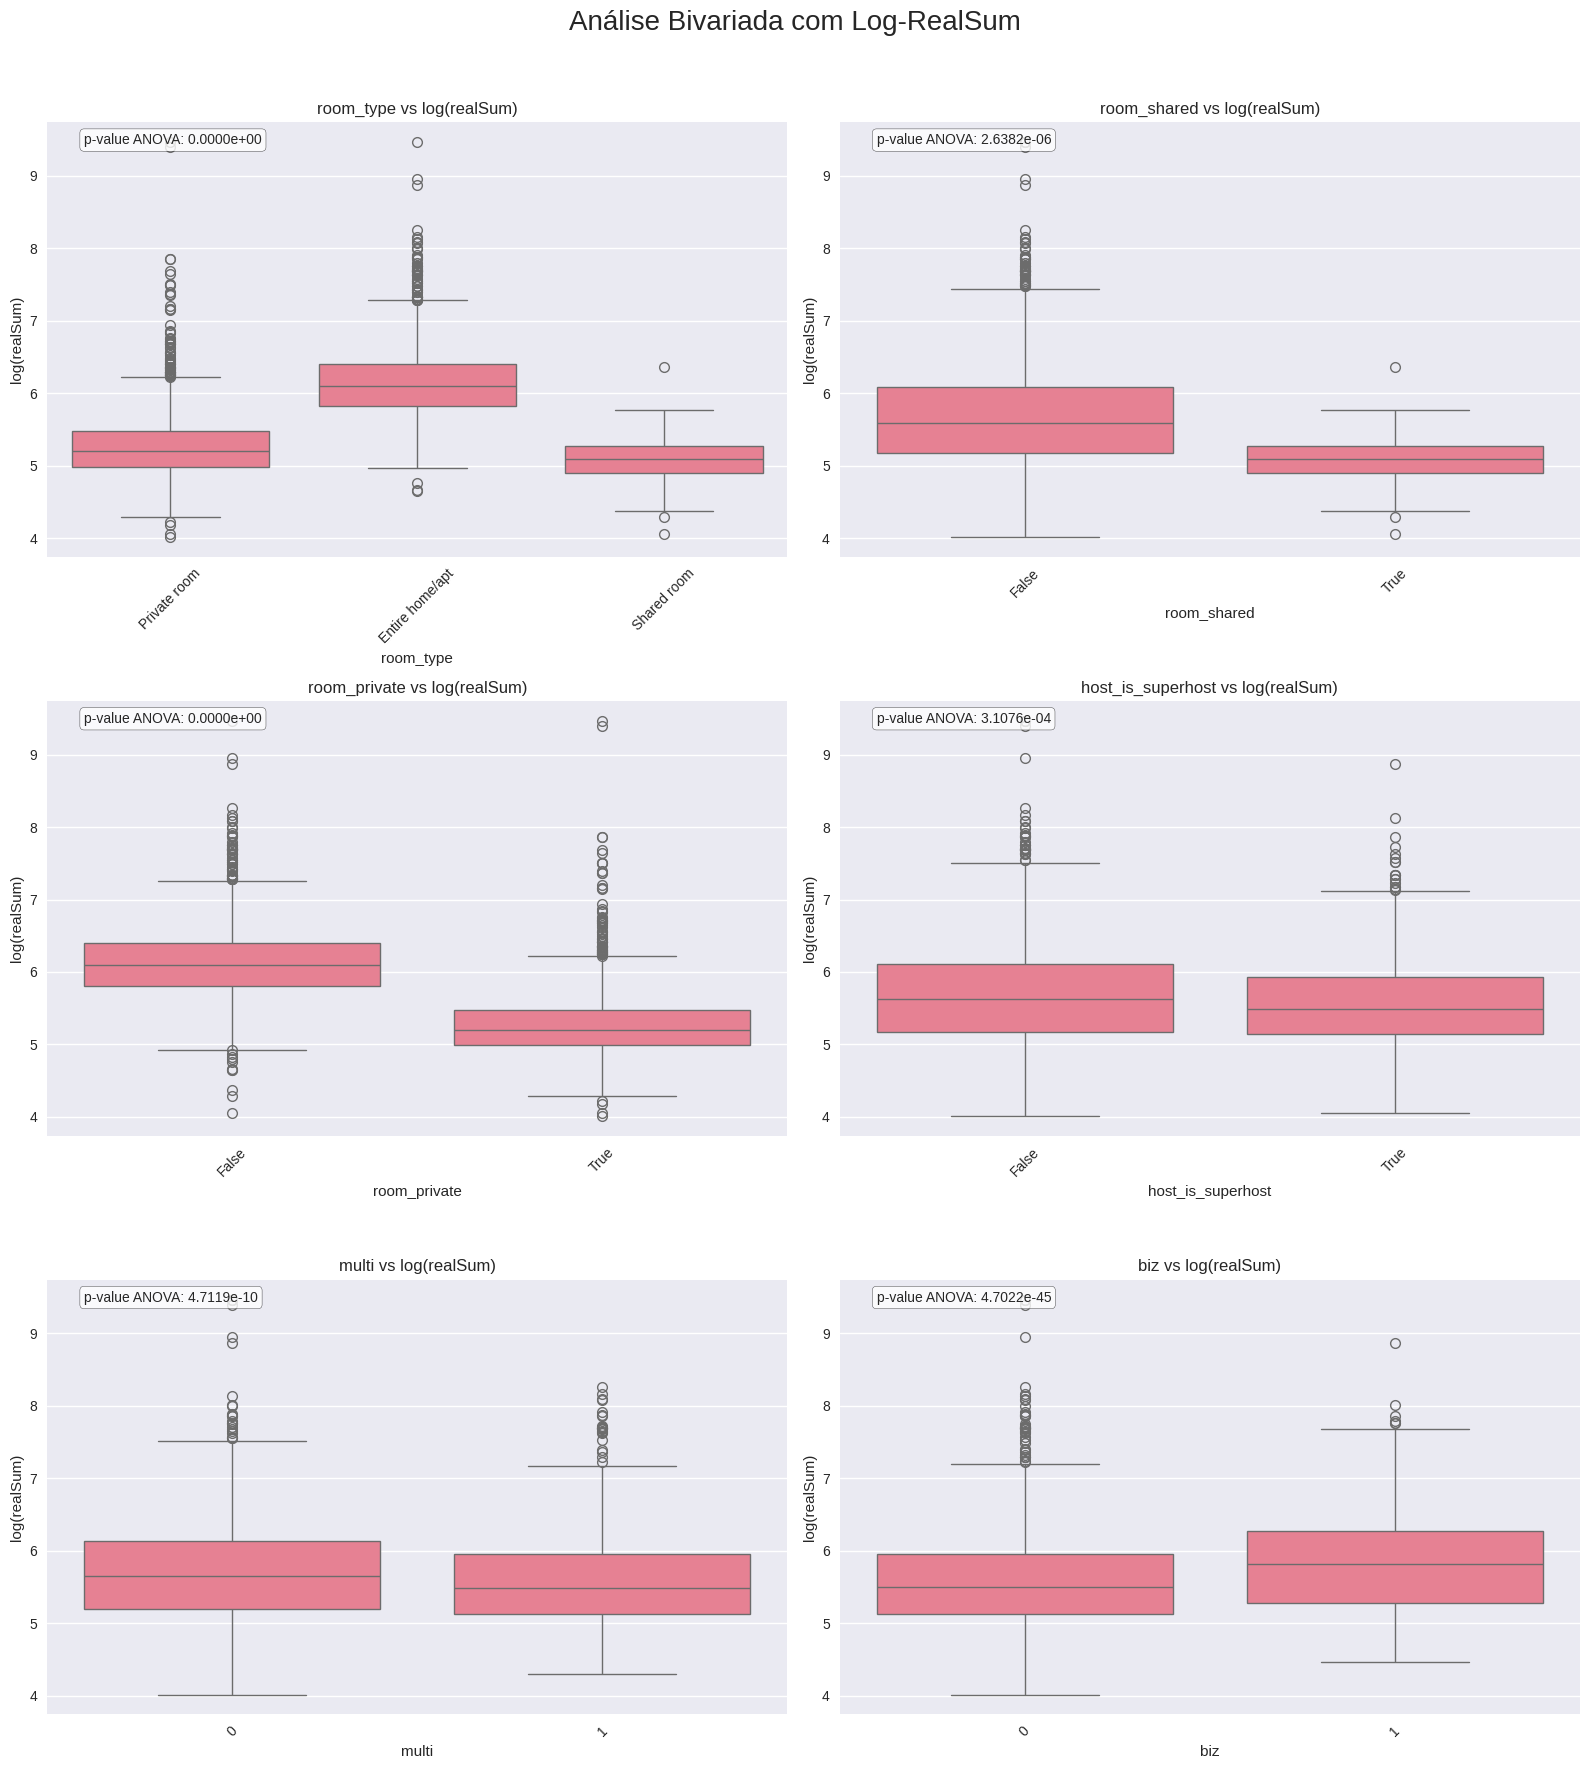

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
import numpy as np


# ✅ Garantir valores válidos para log
df = df[df["realSum"] > 0].copy()
df["realSum_log"] = np.log1p(df["realSum"])

categorical_for_analysis = [
    "room_type",
    "room_shared",
    "room_private",
    "host_is_superhost",
    "multi",
    "biz",
    "cidade",
    "tipo_dia"
]

# ✅ Filtrar apenas variáveis categóricas válidas
valid_categoricals = [
    var for var in categorical_for_analysis
    if var in df.columns and df[var].nunique() > 1
]

print("Variáveis válidas:", valid_categoricals)

# ✅ PROTEÇÃO CONTRA LISTA VAZIA
if len(valid_categoricals) == 0:
    raise ValueError("Nenhuma variável categórica válida para plotar.")

cols = 2
rows = math.ceil(len(valid_categoricals) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
axes = axes.flatten()

fig.suptitle("Análise Bivariada com Log-RealSum", fontsize=20)

for i, var in enumerate(valid_categoricals):
    ax = axes[i]

    sns.boxplot(data=df, x=var, y="realSum_log", ax=ax)

    ax.set_title(f'{var} vs log(realSum)')
    ax.set_ylabel("log(realSum)")
    ax.tick_params(axis='x', rotation=45)

    # ✅ ANOVA segura
    groups = [df[df[var] == c]["realSum_log"].dropna() for c in df[var].dropna().unique()]

    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)
        ax.text(
            0.05, 0.95,
            f'p-value ANOVA: {p_value:.4e}',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

# ✅ Remover eixos vazios
for j in range(len(valid_categoricals), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
